<a href="https://colab.research.google.com/github/tifli/142a-project/blob/main/IOER_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import Packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, cross_val_score, KFold, LeaveOneOut
from sklearn.linear_model import LinearRegression

In [ ]:
K_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE = 0.2

##Import Dataset

In [ ]:
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/tifli/142a-project/refs/heads/main/university_ranking.csv"
df = pd.read_csv(url)
df = df[df['year'] >= 2016]

# List of columns that should be numeric but might contain commas or percent signs
cols_to_clean = ['No. of FTE students', 'No. of students per staff',
                 'International students', 'International Outlook', 'Industry']

for col in cols_to_clean:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.replace('%', '').str.replace('-', ''), errors='coerce')

TARGET = 'Rank'

X = df.drop(['Female:Male ratio', 'rank_prefix', TARGET], axis=1)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

# One-hot encode categorical variables for machine learning models
X_train_encoded = pd.get_dummies(X_train, drop_first=True, dtype=float)
X_test_encoded = pd.get_dummies(X_test, drop_first=True, dtype=float)

# Align columns to ensure test set has the exact same dummy features as train set
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0.0)

scaler = StandardScaler()

# Scale the encoded datasets and maintain DataFrame structure
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=X_train_encoded.columns, index=X_train_encoded.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_test_encoded.columns, index=X_test_encoded.index)

# Construct train_data using the ORIGINAL X_train for OLS
train_data = pd.concat([X_train, y_train], axis=1)

##Linear Regression

####Without "Name" column

In [ ]:
ols = smf.ols(formula='Rank ~ Q("No. of FTE students") + Q("No. of students per staff") + Q("International students") + Overall + Industry + Teaching + Q("Research Environment") + Q("Research Quality") + Q("International Outlook")',
                 data=train_data)
model_lr = ols.fit()
print(model_lr.summary())

# Predict using the unscaled X_test because the model was trained on unscaled train_data
y_pred = model_lr.predict(X_test)
SSE = np.sum((y_test - y_pred)**2)
SST = np.sum((y_test - np.mean(y_train))**2)
osr_reduced = 1 - SSE/SST

print()
print(f"OSR-squared (reduced model): {osr_reduced}")


                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     1085.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:52:51   Log-Likelihood:                -7663.0
No. Observations:                1696   AIC:                         1.535e+04
Df Residuals:                    1686   BIC:                         1.540e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

####With "Name" column

*Use one-hot encoding*

In [ ]:
CAT_VAR = 'Name'
features = [col for col in train_data.columns if col != TARGET]

X_train_scaled_const = sm.add_constant(X_train_scaled)

dependent_var = train_data[TARGET]
model_encode = sm.OLS(dependent_var, X_train_scaled_const).fit()

# Print the first 30 lines of the summary using str()
summary_str = str(model_encode.summary())
print('\n'.join(summary_str.split('\n')[:30]))

X_test_scaled_const = sm.add_constant(X_test_scaled, has_constant='add')
y_pred = model_encode.predict(X_test_scaled_const)

SSE = np.sum((y_test - y_pred)**2)
SST = np.sum((y_test - np.mean(y_train))**2)
osr_full = 1 - SSE/SST
print()
print(f"OSR-squared (full model): {osr_full}")

                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     249.1
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:24:10   Log-Likelihood:                -6012.7
No. Observations:                1696   AIC:                         1.256e+04
Df Residuals:                    1428   BIC:                         1.402e+04
Df Model:                         267                                         
Covariance Type:            nonrobust                                         
                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

**Summary**

Note that both the R-squared and OSR-squared values for the full model above (with "Name") are higher than the reduced model (without "Name"). Hence, we should keep the universities' names in the final model for more accurate predictions.

## CatBoost

In [ ]:
import sys
!{sys.executable} -m pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

cb = CatBoostRegressor(verbose=0)

# Cross-validation
param_grid = {'iterations': [100, 300, 500],
              'learning_rate': [0.01, 0.03, 0.05],
              'depth': [4, 6, 8]}
grid_search = GridSearchCV(cb, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

# Specifying only 'Name' as the categorical feature
cat_features = ['Name']
grid_search.fit(X_train, y_train, cat_features=cat_features)

print(grid_search.best_params_)
cb_best = grid_search.best_estimator_

{'depth': 6, 'iterations': 500, 'learning_rate': 0.05}


In [ ]:
y_train_pred_catboost = cb_best.predict(X_train)
y_test_pred_catboost = cb_best.predict(X_test)

print("=== CatBoost ===")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred_catboost)))
print("Test RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred_catboost)))

=== CatBoost ===
Train RMSE: 1.5033275107236967
Test RMSE : 2.4893993347057566


In [ ]:
# Feature Importances
importances_cb = cb_best.get_feature_importance()
sorted_idx = np.argsort(importances_cb)[::-1]
for i in sorted_idx:
  print(f"{X_train.columns[i]}: {importances_cb[i]:.4f}")

Overall: 64.0928
year: 21.1791
Research Environment: 6.7859
Teaching: 3.9080
Research Quality: 1.6340
No. of students per staff: 0.5518
Industry: 0.5512
International Outlook: 0.5446
No. of FTE students: 0.5212
Name: 0.1273
International students: 0.1042


## Ridge Regression

In [ ]:
from sklearn.linear_model import LassoCV, RidgeCV

loocv = LeaveOneOut()
ridge_cv = RidgeCV(cv=loocv, scoring='neg_mean_squared_error').fit(X_train_scaled, y_train)

print(f"Best lambda: {ridge_cv.alpha_}")

y_pred_l2 = ridge_cv.predict(X_test_scaled)
SSE = np.sum((y_test - y_pred_l2)**2)
SST = np.sum((y_test - np.mean(y_train))**2)
OSR2_l2 = 1 - (SSE/SST)

print(f"OSR2 = {OSR2_l2}")

print("\nFirst 20 Regression coefficients:")
ridge_coefs = pd.Series(ridge_cv.coef_, index=X_train_encoded.columns)
print(ridge_coefs.head(20))

Best lambda: 0.1
OSR2 = 0.9712796480892887

First 20 Regression coefficients:
year                                       9.780239
No. of FTE students                       -0.092647
No. of students per staff                 -1.840838
International students                    -6.064120
Overall                                  114.824420
Teaching                                 -77.099912
Research Environment                     -92.102977
Research Quality                         -59.116828
Industry                                  -5.954813
International Outlook                    -15.381617
Name_Aalto University                     -0.243073
Name_Aarhus University                    -3.390242
Name_Abu Dhabi University                  0.727349
Name_Adelaide University                  -0.993476
Name_Arizona State University (Tempe)     -0.788440
Name_Australian National University       -2.009128
Name_Beijing Normal University            -0.817337
Name_Bielefeld University             

,Feature,OLS,Ridge
0,year,9.351029,9.780239
1,No. of FTE students,0.228662,-0.092647
2,No. of students per staff,-1.136009,-1.840838
3,International students,-5.907923,-6.064120
4,Overall,191.774355,114.824420
5,Teaching,-111.191815,-77.099912
6,Research Environment,-128.080582,-92.102977
7,Research Quality,-83.476542,-59.116828
8,Industry,-10.857721,-5.954813
9,International Outlook,-24.520985,-15.381617


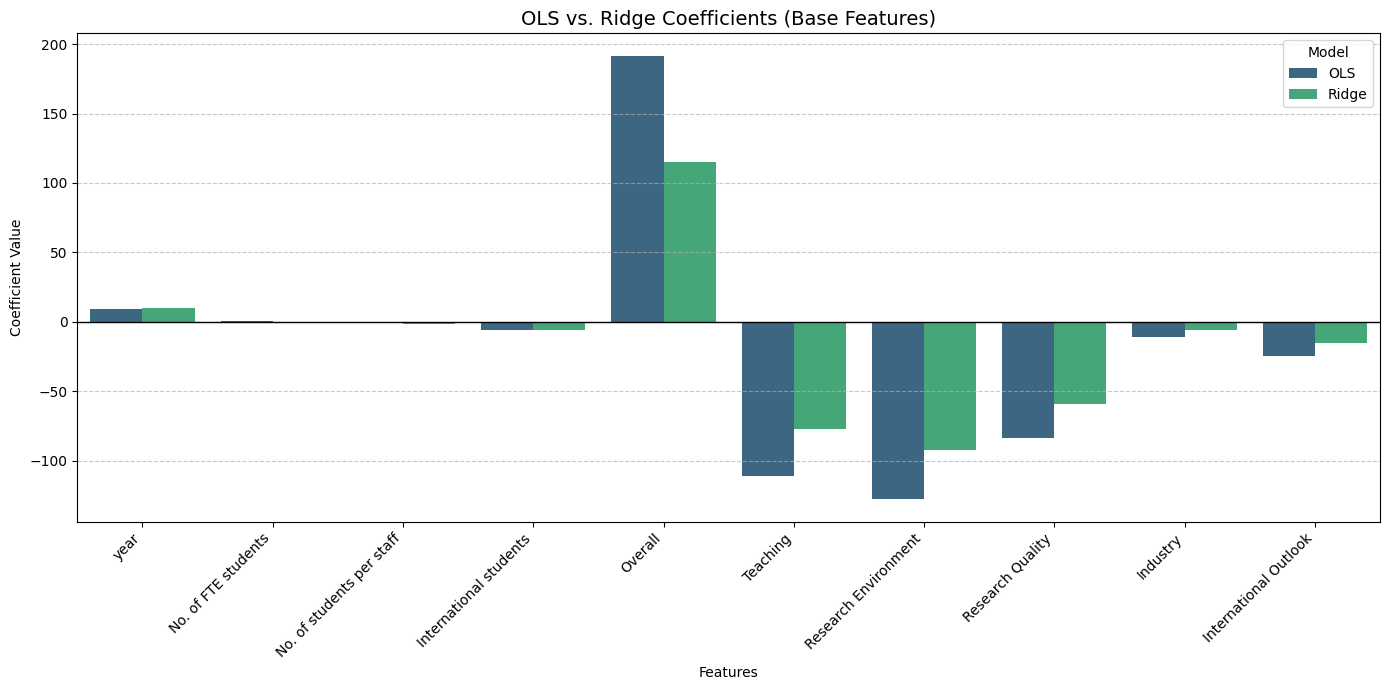

In [ ]:
# Fit standard OLS on the scaled data for a fair comparison with Ridge
from sklearn.linear_model import LinearRegression

ols_scaled = LinearRegression().fit(X_train_scaled, y_train)

# Create a DataFrame with the features and their corresponding coefficients
coef_df = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'OLS': ols_scaled.coef_,
    'Ridge': ridge_cv.coef_
})

# Display the top coefficients table (to avoid a massive table)
display(coef_df.head(15))

# To keep the plot readable, filter down to just the original numeric features
numeric_cols = [c for c in X_train_encoded.columns if not c.startswith('Name_')]
coef_df_numeric = coef_df[coef_df['Feature'].isin(numeric_cols)]

# Melt the DataFrame to make it compatible with Seaborn's hue parameter
coef_df_melted = coef_df_numeric.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# Plotting
plt.figure(figsize=(14, 7))
sns.barplot(data=coef_df_melted, x='Feature', y='Coefficient', hue='Model', palette='viridis')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.title('OLS vs. Ridge Coefficients (Base Features)', fontsize=14)
plt.ylabel('Coefficient Value')
plt.xlabel('Features')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

**Note**

Since none of the regression coefficients are close to zero, all of the features are important for the model. Thus, we must use PCA to combine features that are highly correlated with each. In this case, they are most likely 'Overall', 'Research Environment', and (possibly) 'Teaching'.

##PCA

In [ ]:
from sklearn.decomposition import PCA

# Use the one-hot encoded dataset to include categorical variables
X_train_pca_input = X_train_encoded

# Candidate numbers of principal components
max_components = min(X_train_pca_input.shape[1], 300)
component_grid = list(range(1, max_components + 1, 5))

# K-fold CV object (Use KFold instead of StratifiedKFold for continuous targets)
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}

for k in component_grid:
    fold_R_sq = []

    for train_idx, val_idx in kf.split(X_train_pca_input):
        # Split the training data into one training fold and one validation fold
        X_tr = X_train_pca_input.iloc[train_idx]
        X_val = X_train_pca_input.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # Fit PCA only on the training fold
        pca = PCA(n_components=k)
        X_tr_pca = pca.fit_transform(X_tr)
        X_val_pca = pca.transform(X_val)

        # Fit linear regression on the PCA-transformed training fold
        lr = LinearRegression()
        lr.fit(X_tr_pca, y_tr)

        # Predict on the validation fold
        R = lr.score(X_val_pca, y_val)
        fold_R_sq.append(R)

    # Store the mean CV R-squared for this k
    cv_scores[k] = np.mean(fold_R_sq)
    print(f"k = {k:2d}, mean = {cv_scores[k]:.4f}")

k =  1, mean = 0.0016
k =  6, mean = 0.8352
k = 11, mean = 0.8637
k = 16, mean = 0.8638
k = 21, mean = 0.8639
k = 26, mean = 0.8642
k = 31, mean = 0.8672
k = 36, mean = 0.8674
k = 41, mean = 0.8708
k = 46, mean = 0.8721
k = 51, mean = 0.8711
k = 56, mean = 0.8716
k = 61, mean = 0.8772
k = 66, mean = 0.8780
k = 71, mean = 0.8758
k = 76, mean = 0.8811
k = 81, mean = 0.8796
k = 86, mean = 0.8844
k = 91, mean = 0.8837
k = 96, mean = 0.8893
k = 101, mean = 0.8903
k = 106, mean = 0.8914
k = 111, mean = 0.8945
k = 116, mean = 0.8967
k = 121, mean = 0.8973
k = 126, mean = 0.9009
k = 131, mean = 0.9057
k = 136, mean = 0.9050
k = 141, mean = 0.9076
k = 146, mean = 0.9087
k = 151, mean = 0.9128
k = 156, mean = 0.9157
k = 161, mean = 0.9188
k = 166, mean = 0.9217
k = 171, mean = 0.9254
k = 176, mean = 0.9282
k = 181, mean = 0.9303
k = 186, mean = 0.9370
k = 191, mean = 0.9388
k = 196, mean = 0.9412
k = 201, mean = 0.9443
k = 206, mean = 0.9477
k = 211, mean = 0.9519
k = 216, mean = 0.9530
k = 221,

In [ ]:
# Choose the best number of components
best_k = max(cv_scores, key=cv_scores.get)
print("\nBest number of principal components:", best_k)
print("Best mean CV R-squared:", cv_scores[best_k])


Best number of principal components: 266
Best mean CV R-squared: 0.9669884215364849


In [ ]:
# Refit on the full training set using best_k
pca_best = PCA(n_components=best_k)
X_train_pca_best = pca_best.fit_transform(X_train_encoded)
X_test_pca_best = pca_best.transform(X_test_encoded)

lr_best = LinearRegression()
lr_best.fit(X_train_pca_best, y_train)

train_R_sq = lr_best.score(X_train_pca_best, y_train)
test_R_sq = lr_best.score(X_test_pca_best, y_test)

print("\nFinal model results")
print("Train R-squared:", round(train_R_sq, 4))
print("Test R-squared :", round(test_R_sq, 4))


Final model results
Train R-squared: 0.9789
Test R-squared : 0.9707


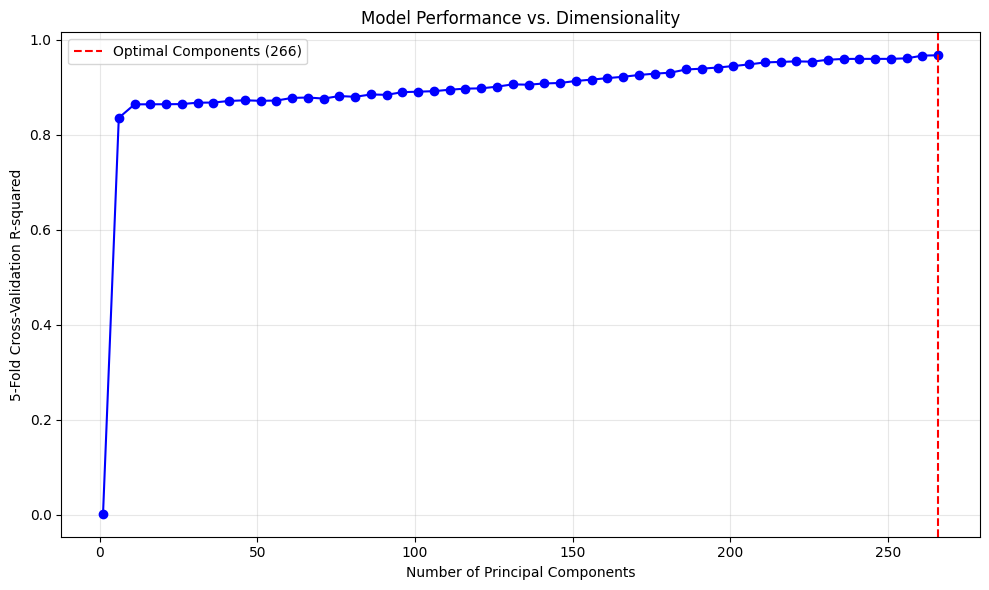

In [ ]:
# --- VISUALIZATION: Cross-Validation R-squared Curve ---
mean_test_scores = [cv_scores[k] for k in component_grid]

plt.figure(figsize=(10, 6))
plt.plot(component_grid, mean_test_scores, marker='o', linestyle='-', color='b')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Optimal Components ({best_k})')
plt.xlabel('Number of Principal Components')
plt.ylabel(f'5-Fold Cross-Validation R-squared')
plt.title('Model Performance vs. Dimensionality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Summary**

The fact that PCA uses over 250 components for predictions and maintained a high R-squared value of 0.97 on the test set indicates that while the features are highly correlated to each other, they still play a significant role in determining the university's rank.

## Preparation for Dashboard

In [ ]:
!pip install dash dash-bootstrap-components
import dash
from dash import dcc, html, Input, Output, State
import dash_bootstrap_components as dbc
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

**Note**

PC1 (Principal Component 1): This is the single new axis that captures the most variation among the universities. Often in ranking data, PC1 represents a general "overall performance" score, summarizing the shared strength across most of the 5 main features.

PC2 (Principal Component 2): This axis captures the second most variation and is completely independent of PC1. It often represents a contrast or trade-off between certain features (for example, universities that score exceptionally high in Industry but lower in Teaching might separate out along this axis).

In [ ]:
# Get the latest year data
df_latest = df[df['year'] == df['year'].max()].copy()
main_feat = ['Teaching', 'Research Environment', 'Research Quality',
             'Industry', 'International Outlook']

# Create Rank Tiers
def get_tier(rank):
    if rank <= 50: return 'Top 50'
    elif rank <= 100: return '51-100'
    elif rank <= 200: return '101-200'
    else: return '201+'

df_latest['Rank_Tier'] = df_latest['Rank'].apply(get_tier)

# Calculate Peer Averages
peer_averages = df_latest.groupby('Rank_Tier')[main_feat].mean().reset_index()

# Prepare PCA on the 5 main features
pca_2 = PCA(n_components=2)
pca_coords = pca_2.fit_transform(df_latest[main_feat].fillna(df_latest[main_feat].mean()))
df_latest['PC1'] = pca_coords[:, 0]
df_latest['PC2'] = pca_coords[:, 1]

# Prepare coefficients dataframe (using previously fitted ols_scaled and ridge_cv)
coef_df_main = coef_df[coef_df['Feature'].isin(main_feat)]

### Build App

In [30]:
# Prepare CatBoost Feature Importance Figure
cb_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances_cb
}).sort_values(by='Importance', ascending=False)

fig_cb_importance = px.bar(cb_importance_df.head(10), x='Importance',
                           y='Feature', orientation='h',
                           title="CatBoost Top 10 Feature Importances")
fig_cb_importance.update_layout(yaxis={'categoryorder': 'total ascending'})

app = dash.Dash(__name__, external_stylesheets=[dbc.themes.FLATLY])

app.layout = dbc.Container([
    dbc.Row([
        dbc.Col(html.H1("University Ranking Dashboard",
                        className="text-center text-primary my-4 fw-bold"),
                width=12)
    ]),

    dbc.Card([
        dbc.CardBody([
            dbc.Row([
                dbc.Col([
                    html.Label("Select University:", className="fw-bold"),
                    dcc.Dropdown(
                        id='uni-dropdown',
                        options=[{'label': name, 'value': name} for name in df_latest['Name'].unique()],
                        value=df_latest['Name'].iloc[0],
                        className="mb-2"
                    )
                ], width=12)
            ])
        ])
    ], className="mb-4 shadow-sm"),

    dbc.Row([
        dbc.Col([dbc.Card([dbc.CardBody([dcc.Graph(id='radar-chart')])],
                          className="mb-4 shadow-sm")], width=6),
        dbc.Col([dbc.Card([dbc.CardBody([dcc.Graph(id='pca-plot')])],
                          className="mb-4 shadow-sm")], width=6)
    ]),

    dbc.Row([
        dbc.Col([dbc.Card([dbc.CardBody([dcc.Graph(id='weights-chart')])],
                          className="mb-4 shadow-sm")], width=6),
        dbc.Col([dbc.Card([dbc.CardBody([dcc.Graph(id='cb-importance-chart',
                                                   figure=fig_cb_importance)])],
                          className="mb-4 shadow-sm")], width=6)
    ]),

    dbc.Card([
        dbc.CardHeader(html.H3("Simulator: Adjust Feature Scores",
                               className="m-0 text-white bg-primary")),
        dbc.CardBody([
            html.Div(id='sliders-container'),
            html.Hr(),
            html.H4(id='simulator-output', className="mt-4 mb-2 text-center text-success fw-bold")
        ])
    ], className="mb-5 shadow-sm")
], fluid=True, className="bg-light py-3")

@app.callback(
    Output('radar-chart', 'figure'),
    Output('pca-plot', 'figure'),
    Output('weights-chart', 'figure'),
    Output('sliders-container', 'children'),
    Input('uni-dropdown', 'value')
)
def update_dashboard(selected_uni):
    # Radar Chart
    uni_data = df_latest[df_latest['Name'] == selected_uni].iloc[0]
    tier = uni_data['Rank_Tier']
    peer_data = peer_averages[peer_averages['Rank_Tier'] == tier].iloc[0]

    fig_radar = go.Figure()
    fig_radar.add_trace(go.Scatterpolar(
        r=[uni_data[p] for p in main_feat], theta=main_feat, fill='toself', name=selected_uni
    ))
    fig_radar.add_trace(go.Scatterpolar(
        r=[peer_data[p] for p in main_feat], theta=main_feat, fill='toself', name=f'{tier} Average'
    ))
    fig_radar.update_layout(title="Feature Scores vs. Peer Average",
                            polar=dict(radialaxis=dict(visible=True, range=[0, 100])))

    # PCA Plot
    fig_pca = px.scatter(df_latest, x='PC1', y='PC2', color='Rank_Tier',
                         hover_name='Name', title="PCA: University Clusters")
    fig_pca.add_trace(go.Scatter(x=[uni_data['PC1']], y=[uni_data['PC2']],
                                 mode='markers',
                                 marker=dict(size=15, color='red', symbol='star'),
                                 name='Selected'))

    # Weights Chart
    fig_weights = px.bar(coef_df_melted[coef_df_melted['Feature'].isin(main_feat)],
                         x='Feature', y='Coefficient', color='Model',
                         barmode='group',
                         title="OLS vs Ridge Coefficients (Main Features)")

    # Sliders
    sliders = []
    for p in main_feat:
        val = uni_data[p]
        if pd.isna(val): val = 50
        sliders.append(dbc.Row([
            dbc.Col(html.Label(p, className="fw-bold"), width=3),
            dbc.Col(dcc.Slider(id=f'slider-{p}', min=0, max=100, step=1,
                               value=float(val),
                               tooltip={"placement": "bottom", "always_visible": True}), width=9)
        ], className="mb-3 align-items-center"))

    return fig_radar, fig_pca, fig_weights, sliders

@app.callback(
    Output('simulator-output', 'children'),
    [Input(f'slider-{p}', 'value') for p in main_feat],
    State('uni-dropdown', 'value')
)
def update_simulation(t, re, rq, i, io, selected_uni):
    # Simplified simulation logic for demonstration
    # In a full app, standardize these inputs using the fitted scaler and apply the Ridge coefficients
    new_overall = 0.3 * t + 0.3 * re + 0.3 * rq + 0.05 * i + 0.05 * io
    est_rank = 1000 - (new_overall * 10)
    if est_rank < 1: est_rank = 1
    tier = get_tier(est_rank)
    return f"Predicted Overall Score: {new_overall:.1f} | Estimated Rank: {int(est_rank)} ({tier})"

if __name__ == '__main__':
    from google.colab import output
    port = 8050
    print("\n*** PLEASE CLICK THE LINK BELOW TO OPEN THE DASHBOARD ***")
    print(output.eval_js(f"google.colab.kernel.proxyPort({port})"))
    print("**********************************************************\n")
    app.run(port=port)



*** PLEASE CLICK THE LINK BELOW TO OPEN THE DASHBOARD ***
https://8050-m-s-kkb-usc1b1-36vnldupj6v95-b.us-central1-1.prod.colab.dev
**********************************************************

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [30/Apr/2026 20:09:18] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [30/Apr/2026 20:09:18] "GET /_dash-component-suites/dash/deps/polyfill@7.v4_1_0m1777576321.12.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [30/Apr/2026 20:09:18] "GET /_dash-component-suites/dash/deps/react@18.v4_1_0m1777576321.3.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [30/Apr/2026 20:09:18] "GET /_dash-component-suites/dash/dcc/dash_core_components.v4_1_0m1777576321.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [30/Apr/2026 20:09:18] "GET /_dash-component-suites/dash/dcc/dash_core_components-shared.v4_1_0m1777576321.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [30/Apr/2026 20:09:18] "GET /_dash-component-suites/dash/dash_table/bundle.v7_1_0m1777576321.js HTTP/1